In [ ]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # points to src/
from shared_modeling import load_or_create_master_split_ids, run_model_experiment

In [ ]:
predictors = ['V1AD02a', 'V1AD02b', 'V1AD02c', 'V1AD02d', 'V1AD02e', 'V1AD02f', 'V1AD02g','V1AD02h','V1AD02i', 'V1AD02j', 'V1AD02k']
df = pd.read_csv('../../Data/V1A.csv', usecols=predictors + ['PublicID'])

In [ ]:
df_outcomes = pd.read_csv('../../Data/Modified/Outcome.csv', usecols=['PublicID', 'MH_outcome'])

# Create the master split once and persist it for reuse in other notebooks.
split_path = 'master_split_ids.csv'
train_ids, test_ids = load_or_create_master_split_ids(df_outcomes, split_path)
df_outcomes

,PublicID,MH_outcome
0,00004O,1
1,00007I,1
2,00008G,0
3,00015J,0
4,00016H,1
...,...,...
7736,17349I,1
7737,17350A,1
7738,17351V,0
7739,17352T,1


In [4]:
df = pd.merge(df, df_outcomes, on='PublicID', how='inner')
df

,PublicID,V1AD02a,V1AD02b,V1AD02c,V1AD02d,V1AD02e,V1AD02f,V1AD02g,V1AD02h,V1AD02i,V1AD02j,V1AD02k,MH_outcome
0,00004O,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1
1,00007I,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1
2,00008G,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,0
3,00015J,1.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,0
4,00016H,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7736,17349I,1.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,1
7737,17350A,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1
7738,17351V,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0
7739,17352T,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1


In [5]:
start_col = df.columns.get_loc('V1AD02a')
end_col = df.columns.get_loc('V1AD02k') + 1  # +1 because the range end is exclusive

# Sum the specified columns row-wise and create a new column with the results
df['V1AD02a_sum'] = df.iloc[:, start_col:end_col].sum(axis=1)

In [6]:
X = df.drop(['MH_outcome', 'PublicID'], axis=1)
y = df['MH_outcome']

train_df = df[df['PublicID'].isin(train_ids)].copy()
test_df = df[df['PublicID'].isin(test_ids)].copy()

X_train = train_df.drop(['MH_outcome', 'PublicID'], axis=1)
X_test = test_df.drop(['MH_outcome', 'PublicID'], axis=1)
y_train = train_df['MH_outcome']
y_test = test_df['MH_outcome']

y.value_counts()

MH_outcome
0    4591
1    3150
Name: count, dtype: int64

In [7]:
# Run the LR pipeline with macro F1 grid search.
best_model, y_pred, metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'lr',
    predictors
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found: {'classifier__C': 0.1, 'classifier__l1_ratio': 0.5}
Best Macro F1 Score: 0.5555
Model Coefficients:
num__V1AD02a: 0.2054654328913956
num__V1AD02b: 0.06946013312823776
num__V1AD02c: 0.06572325821023818
num__V1AD02d: 0.07682785778565947
num__V1AD02e: 0.08078369977609934
num__V1AD02f: 0.04214549205686618
num__V1AD02g: -0.38577510319828073
num__V1AD02h: -0.07549563818153511
num__V1AD02i: 0.0
num__V1AD02j: 0.024410222387060625
num__V1AD02k: 0.0042824260297425155
Evaluation Metrics for LR with shared preprocessing and macro F1 grid search:
Accuracy: 0.5668
Precision: 0.5830
Recall: 0.5840
F1-score: 0.5667
ROC AUC: 0.6107


In [8]:
# Run the RF pipeline with macro F1 grid search.
best_model, y_pred, metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'rf',
    predictors
)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 7, 'classifier__n_estimators': 600}
Best Macro F1 Score: 0.5482
Feature Importances:
num__V1AD02a: 0.15178489623994038
num__V1AD02b: 0.11042153935364367
num__V1AD02c: 0.07152628988950137
num__V1AD02d: 0.07340380795479472
num__V1AD02e: 0.07763095704690479
num__V1AD02f: 0.07736504547842661
num__V1AD02g: 0.16746161655023328
num__V1AD02h: 0.09763130491993799
num__V1AD02i: 0.07012474753885814
num__V1AD02j: 0.05378263102303601
num__V1AD02k: 0.04886716400472311
Evaluation Metrics for RF with shared preprocessing and macro F1 grid search:
Accuracy: 0.5455
Precision: 0.5565
Recall: 0.5578
F1-score: 0.5449
ROC AUC: 0.5805


In [9]:
# Run the XGBoost pipeline with macro F1 grid search.
best_model, y_pred, metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'xgb',
    predictors
)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 60, 'classifier__subsample': 0.5}
Best Macro F1 Score: 0.5624
Feature Importances:
num__V1AD02a: 0.17606380581855774
num__V1AD02b: 0.08577906340360641
num__V1AD02c: 0.06091175973415375
num__V1AD02d: 0.060340020805597305
num__V1AD02e: 0.05770440772175789
num__V1AD02f: 0.045521918684244156
num__V1AD02g: 0.20833025872707367
num__V1AD02h: 0.056464679539203644
num__V1AD02i: 0.08177217096090317
num__V1AD02j: 0.08727721124887466
num__V1AD02k: 0.0798346996307373
Evaluation Metrics for XGB with shared preprocessing and macro F1 grid search:
Accuracy: 0.5823
Precision: 0.5904
Recall: 0.5931
F1-score: 0.5811
ROC AUC: 0.6241


In [10]:
# Run the SVM pipeline with macro F1 grid search.
best_model, y_pred, metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'svm',
    predictors
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'classifier__estimator__C': 0.1, 'classifier__estimator__gamma': 0.1, 'classifier__estimator__kernel': 'rbf'}
Best Macro F1 Score: 0.5574
Skipping feature-level SVM output to keep notebook output compact.
Evaluation Metrics for SVM with shared preprocessing and macro F1 grid search:
Accuracy: 0.5739
Precision: 0.5805
Recall: 0.5830
F1-score: 0.5724
ROC AUC: 0.5985


Cross-validated scores: [0.62843296 0.6192401  0.6200485  0.62489895 0.61681487]
Best parameters: {'C': 1, 'penalty': 'l2'}
Accuracy: 0.6044, Precision: 0.5972, Recall: 0.1344, F1-score: 0.2194



15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\91799\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 54, in _check_solver
    raise ValueError(
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

One or more of the test scor

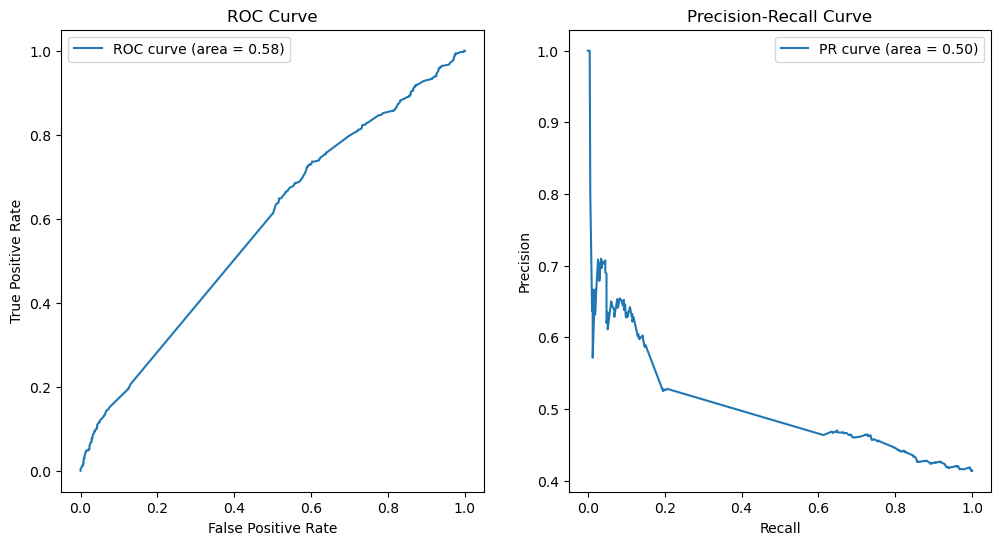

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


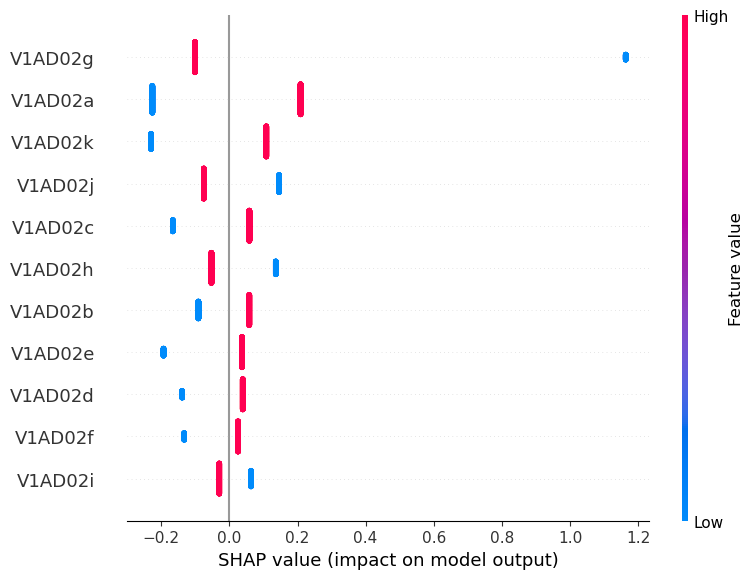

           V1AD02a      V1AD02b      V1AD02c      V1AD02d      V1AD02e  \
count  9265.000000  9265.000000  9265.000000  9265.000000  9265.000000   
mean      1.535888     1.649110     1.746681     1.813923     1.814247   
std       0.498737     0.477274     0.434935     0.389190     0.388928   
min       1.000000     1.000000     1.000000     1.000000     1.000000   
25%       1.000000     1.000000     1.000000     2.000000     2.000000   
50%       2.000000     2.000000     2.000000     2.000000     2.000000   
75%       2.000000     2.000000     2.000000     2.000000     2.000000   
max       2.000000     2.000000     2.000000     2.000000     2.000000   

           V1AD02f      V1AD02g      V1AD02h      V1AD02i      V1AD02j  \
count  9265.000000  9264.000000  9265.000000  9265.000000  9265.000000   
mean      1.820291     1.860751     1.698759     1.667458     1.647706   
std       0.383965     0.346225     0.458822     0.471149     0.477711   
min       1.000000     1.000000     1

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.


<Axes: >

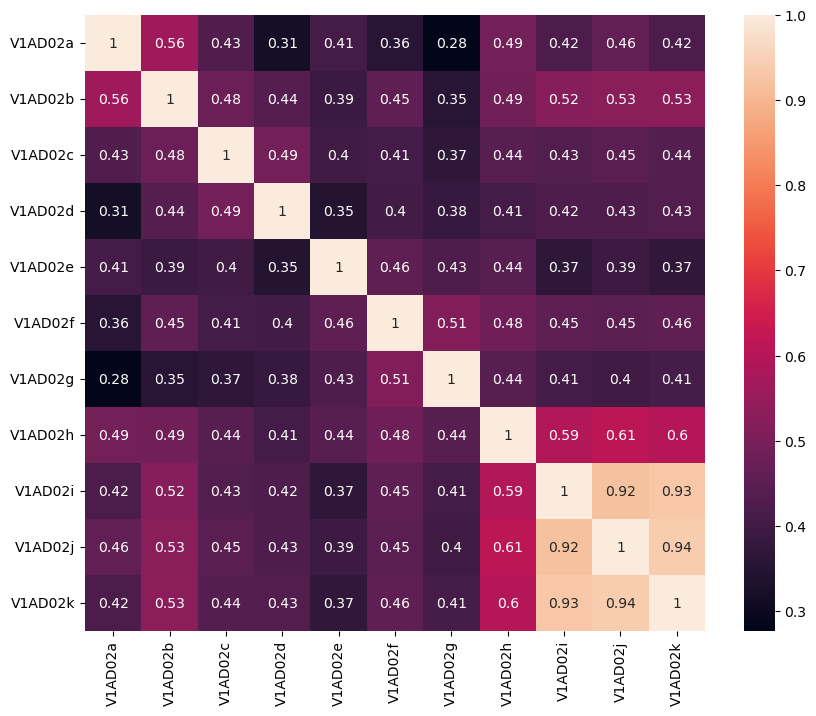

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, auc
# import shap

# # Assuming df is your dataframe after initial loading and merging

# # Handling missing values
# # df.fillna(df.median(), inplace=True)  # or df.mean()

# # Splitting data into features and target
# y = merged_data['MH_outcome']
# X = merged_data.drop(['PublicID', 'MH_outcome'], axis=1)

# # Splitting data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Feature scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Logistic Regression Model
# model = LogisticRegression(solver='liblinear')
# model.fit(X_train_scaled, y_train)

# # Cross-Validation
# scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
# print("Cross-validated scores:", scores)

# # Hyperparameter Tuning
# param_grid = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2']}
# grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5)
# grid_search.fit(X_train_scaled, y_train)
# print("Best parameters:", grid_search.best_params_)

# # Model Evaluation
# y_pred = model.predict(X_test_scaled)
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)
# print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

# # ROC-AUC and Precision-Recall Curves
# y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
# fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
# roc_auc = auc(fpr, tpr)
# precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
# pr_auc = auc(recall, precision)

# # Plotting ROC and Precision-Recall Curves
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(recall, precision, label=f'PR curve (area = {pr_auc:.2f})')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()
# plt.show()

# # Model Interpretability with SHAP
# explainer = shap.Explainer(model, X_train_scaled)
# shap_values = explainer(X_test_scaled)
# shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# # Basic EDA
# # Print descriptive statistics
# print(df.describe())

# # Pairplot (this may be time-consuming for large datasets)
# # sns.pairplot(df)

# # Correlation matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(df.corr(), annot=True)
